# Practical: Ambient seismic noise and station quality control

**Part 1 — Exploring continuous seismic waveforms and quality control**  
**Part 2 — Characterizing background noise with PPSD**  
**Part 3 — How does seismic noise vary through the week?**  
**Part 4 — Ambient noise versus an earthquake-rich wavefield**

In this practical we work with **broadband seismic stations of the KOERI network (KO) around the Sea of Marmara (Türkiye)**.
The continuous ambient-noise dataset covers **one week: 1–7 August 2019** (Julian days 213–219), recorded at 100 Hz on three components.

On **26 September 2019**, a moderate earthquake (**Mw ≈ 5.7–5.8**, depending on the agency) struck the Sea of Marmara south of **Silivri**.
Its approximate epicenter was:

- **Latitude:** 40.890° N
- **Longitude:** 28.173° E

In Part 4 we also look at a few hours of data from **24 September 2019**, two days before the main shock, when the region produced many smaller earthquakes.

In this notebook we will learn to:

- read and inspect miniSEED waveform data,
- inspect seismic metadata (StationXML) and the instrument response,
- identify dead or filled waveform intervals,
- compute and interpret a Probabilistic Power Spectral Density (PPSD),
- examine daily and weekly changes in ambient noise,
- compare ambient noise with an earthquake-rich wavefield using spectrograms.



## 0. Google Colab setup

This notebook is designed to run directly in **Google Colab** (`Runtime → Run all` works from top to bottom).
All data are downloaded automatically from the [GitHub Release](https://github.com/sebmagia/applied_seismology_rwth/releases/tag/ambient-noise-practical-v1) of this practical.

| Dataset | Role in this notebook | Download size |
|---|---|---|
| `KO.MDNY` (1 week) | quality-control example (Part 1) | ~250 MB |
| `KO.SLVT` (1 week) | main station (Parts 2–4) | ~190 MB |
| `KO.BGKT` (1 week) | optional, appears only on the map | ~230 MB |
| `waveforms_foreshocks.zip` | earthquake-rich interval (Part 4) | ~20 MB |
| `marmara_coastline.csv` | coastline for the map | 11 KB |

The first cell installs ObsPy. NumPy, SciPy, pandas and Matplotlib are already available in Colab.

In [1]:
# ObsPy is not pre-installed in Colab; everything else used here is.
!pip -q install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 59.4 MB/s eta 0:00:00


## 1. Imports

In [2]:
from pathlib import Path
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

from obspy import Stream, UTCDateTime, read, read_inventory
from obspy.signal import PPSD

## 2. Download the teaching dataset

Each station ZIP file in the release contains one folder named

```text
NETWORK.STATION.LOCATION        e.g.  KO.SLVT.00/
```

with seven daily miniSEED files (`KO.SLVT.00.HH.2019.213.mseed` … `.219.mseed`) and the StationXML metadata (`KO.SLVT.HH.xml`).

The QC and main stations are always downloaded because the notebook needs them.
Set `DOWNLOAD_OPTIONAL_STATION = False` if classroom bandwidth is limited; this skips `KO.BGKT`, which then simply does not appear on the map.

In [3]:
QC_STATION = "KO.MDNY"        # Part 1: quality-control example
MAIN_STATION = "KO.SLVT"      # Parts 2-4: main analysis station
OPTIONAL_STATION = "KO.BGKT"  # optional comparison station (map only)

DOWNLOAD_OPTIONAL_STATION = True

STATIONS_TO_DOWNLOAD = [QC_STATION, MAIN_STATION]
if DOWNLOAD_OPTIONAL_STATION:
    STATIONS_TO_DOWNLOAD.append(OPTIONAL_STATION)

RELEASE_BASE = (
    "https://github.com/sebmagia/applied_seismology_rwth/"
    "releases/download/ambient-noise-practical-v1"
)

# In Colab this resolves to /content/ambient_noise_data
DATA_ROOT = Path.cwd() / "ambient_noise_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

YEAR = 2019
AVAILABLE_DAYS = range(213, 220)   # 1-7 August 2019
JULIAN_DAY = 213                   # day analysed in Parts 1-2; any value in AVAILABLE_DAYS works

day_start = UTCDateTime(year=YEAR, julday=JULIAN_DAY)
print(f"Data folder:  {DATA_ROOT}")
print(f"Analysed day: {YEAR}-{JULIAN_DAY:03d} = {day_start.date} ({day_start.strftime('%A')})")

Data folder:  /content/ambient_noise_data
Analysed day: 2019-213 = 2019-08-01 (Thursday)


In [4]:
def station_dir_for(station_code):
    network, station = station_code.split(".")
    return DATA_ROOT / f"{network}.{station}.00"


def is_complete(station_dir):
    # An interrupted extraction can leave a half-filled folder behind.
    n_mseed = len(list(station_dir.glob("*.mseed")))
    n_xml = len(list(station_dir.glob("*.xml")))
    return n_mseed == len(AVAILABLE_DAYS) and n_xml >= 1


def download_station(station_code):
    # Download and extract one station archive unless it is already present.
    station_dir = station_dir_for(station_code)

    if station_dir.exists() and is_complete(station_dir):
        print(f"{station_code}: already available -> {station_dir}")
        return station_dir

    url = f"{RELEASE_BASE}/{station_code}_noise.zip"
    zip_path = DATA_ROOT / f"{station_code}_noise.zip"

    print(f"{station_code}: downloading {url} ...")
    urllib.request.urlretrieve(url, zip_path)

    print(f"{station_code}: extracting {zip_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_ROOT)
    zip_path.unlink(missing_ok=True)

    if not is_complete(station_dir):
        raise FileNotFoundError(
            f"{station_dir} is missing files after extraction. "
            "Delete the folder and run this cell again."
        )

    print(f"{station_code}: ready -> {station_dir}")
    return station_dir


for station_code in STATIONS_TO_DOWNLOAD:
    download_station(station_code)

COAST_FILE = DATA_ROOT / "marmara_coastline.csv"
if not COAST_FILE.exists():
    urllib.request.urlretrieve(f"{RELEASE_BASE}/marmara_coastline.csv", COAST_FILE)
print(f"Coastline: {COAST_FILE}")

KO.MDNY: downloading https://github.com/sebmagia/applied_seismology_rwth/releases/download/ambient-noise-practical-v1/KO.MDNY_noise.zip ...
KO.MDNY: extracting KO.MDNY_noise.zip ...
KO.MDNY: ready -> /content/ambient_noise_data/KO.MDNY.00
KO.SLVT: downloading https://github.com/sebmagia/applied_seismology_rwth/releases/download/ambient-noise-practical-v1/KO.SLVT_noise.zip ...
KO.SLVT: extracting KO.SLVT_noise.zip ...
KO.SLVT: ready -> /content/ambient_noise_data/KO.SLVT.00
KO.BGKT: downloading https://github.com/sebmagia/applied_seismology_rwth/releases/download/ambient-noise-practical-v1/KO.BGKT_noise.zip ...
KO.BGKT: extracting KO.BGKT_noise.zip ...
KO.BGKT: ready -> /content/ambient_noise_data/KO.BGKT.00
Coastline: /content/ambient_noise_data/marmara_coastline.csv


## 3. Contextualizing the dataset: station map

Each station folder contains StationXML metadata, so we can read the station coordinates directly from the dataset and plot them together with the **2019 Silivri earthquake epicenter**.
The coastline comes from `marmara_coastline.csv`, downloaded above, so no geospatial packages are needed.

In [5]:
def load_all_station_coordinates(data_root):
    rows = []
    for xml_file in sorted(data_root.glob("KO.*.00/*.xml")):
        inv = read_inventory(str(xml_file))
        for net in inv:
            for sta in net:
                rows.append({
                    "network": net.code,
                    "station": sta.code,
                    "latitude": sta.latitude,
                    "longitude": sta.longitude,
                    "elevation_m": sta.elevation,
                })
    return pd.DataFrame(rows)


stations = load_all_station_coordinates(DATA_ROOT)
coast = pd.read_csv(COAST_FILE)

stations

,network,station,latitude,longitude,elevation_m
0,KO,BGKT,41.1810,28.7730,80.0
1,KO,MDNY,40.3709,28.8846,116.0
2,KO,SLVT,41.2288,28.2098,180.0


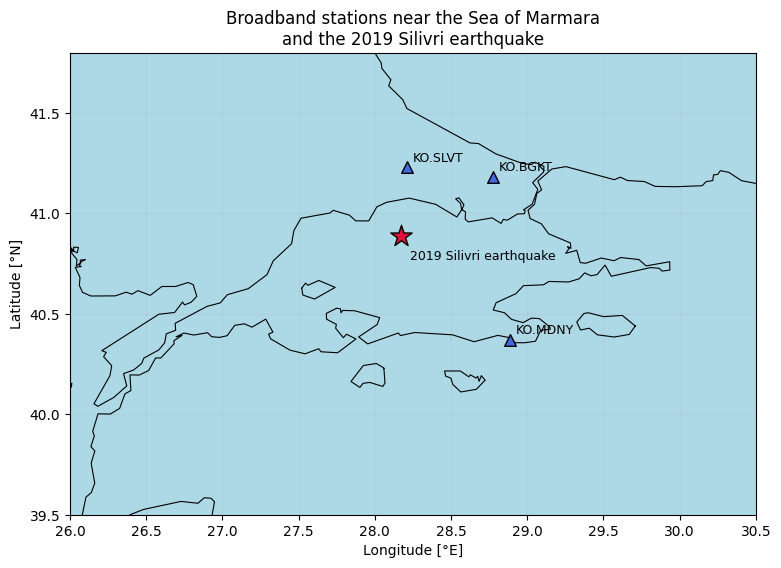

In [6]:
EVENT_LAT = 40.890
EVENT_LON = 28.173

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor("lightblue")

for _, seg in coast.groupby("segment"):
    ax.plot(seg["longitude"], seg["latitude"], color="black", linewidth=0.8, zorder=2)

for _, row in stations.iterrows():
    ax.scatter(row["longitude"], row["latitude"], marker="^", s=70,
               color="royalblue", edgecolor="black", zorder=4)
    ax.text(row["longitude"] + 0.04, row["latitude"] + 0.03,
            f'{row["network"]}.{row["station"]}', fontsize=9, zorder=5)

ax.scatter(EVENT_LON, EVENT_LAT, marker="*", s=260,
           color="crimson", edgecolor="black", zorder=6)
ax.text(EVENT_LON + 0.06, EVENT_LAT - 0.12, "2019 Silivri earthquake", fontsize=9, zorder=6)

ax.set_xlim(26.0, 30.5)
ax.set_ylim(39.5, 41.8)
ax.set_aspect(1 / np.cos(np.radians(40.65)))   # keep distances undistorted at this latitude
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title("Broadband stations near the Sea of Marmara\nand the 2019 Silivri earthquake")
ax.grid(alpha=0.2)

plt.show()

### Exercise 0

- Which stations are closest to the Sea of Marmara?
- Which stations are closest to the 2019 earthquake epicenter?
- Why might station location matter for both earthquake recordings and ambient-noise measurements?

## 4. Helper function to build waveform and metadata paths

In [7]:
def build_station_paths(station_code, year=YEAR, jday=JULIAN_DAY):
    network, station = station_code.split(".")
    station_dir = station_dir_for(station_code)

    waveform_file = station_dir / f"{network}.{station}.00.HH.{year}.{jday:03d}.mseed"
    stationxml_file = station_dir / f"{network}.{station}.HH.xml"

    if not waveform_file.exists():
        raise FileNotFoundError(
            f"No waveform for {station_code}, year={year}, jday={jday:03d}. "
            f"Available days: {AVAILABLE_DAYS.start}-{AVAILABLE_DAYS.stop - 1}."
        )
    if not stationxml_file.exists():
        raise FileNotFoundError(f"No StationXML found: {stationxml_file}")

    return waveform_file, stationxml_file

# Part 1 — Quality control example using KO.MDNY

## 5. Read one day of continuous data for the QC station

We start with **KO.MDNY**, because it provides a useful example of how apparently continuous data may still contain invalid intervals.

In [8]:
qc_data_file, qc_stationxml_file = build_station_paths(QC_STATION)

print("Waveform:  ", qc_data_file)
print("StationXML:", qc_stationxml_file)

st_qc = read(str(qc_data_file))
print(st_qc)

Waveform:   /content/ambient_noise_data/KO.MDNY.00/KO.MDNY.00.HH.2019.213.mseed
StationXML: /content/ambient_noise_data/KO.MDNY.00/KO.MDNY.HH.xml
3 Trace(s) in Stream:
KO.MDNY.00.HHE | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples
KO.MDNY.00.HHN | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples
KO.MDNY.00.HHZ | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples


### Exercise 1

Identify:

1. number of components,
2. channel names,
3. sampling rate,
4. record duration,
5. number of samples per component.

In [9]:
for tr in st_qc:
    print("=" * 70)
    print(tr.id)
    print(tr.stats)

KO.MDNY.00.HHE
         network: KO
         station: MDNY
        location: 00
         channel: HHE
       starttime: 2019-08-01T00:00:00.000000Z
         endtime: 2019-08-02T00:00:00.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 2579, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 4096, 'filesize': 1048576})
KO.MDNY.00.HHN
         network: KO
         station: MDNY
        location: 00
         channel: HHN
       starttime: 2019-08-01T00:00:00.000000Z
         endtime: 2019-08-02T00:00:00.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 2671, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 4096, 'filesize': 1048576})
KO.MDNY.00.HHZ
         network: KO
         stati

## 6. Plot the three components (stream plot)

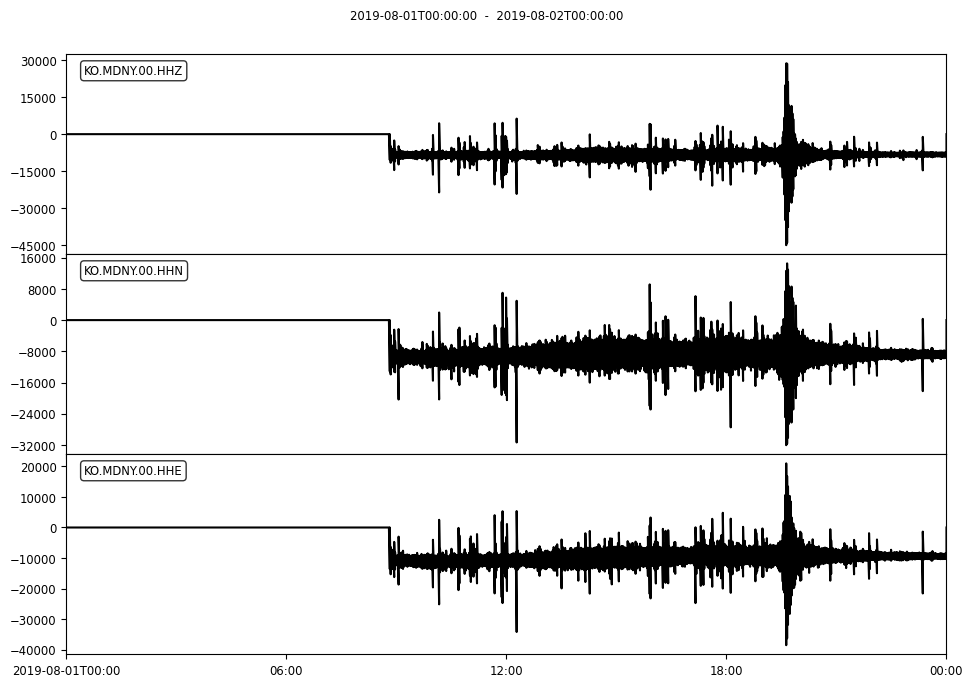

In [10]:
st_qc.plot(equal_scale=False, size=(1000, 700));

## 7. Plot the same day as a dayplot

A **dayplot** is often useful for a quick visual scan of a long continuous record.

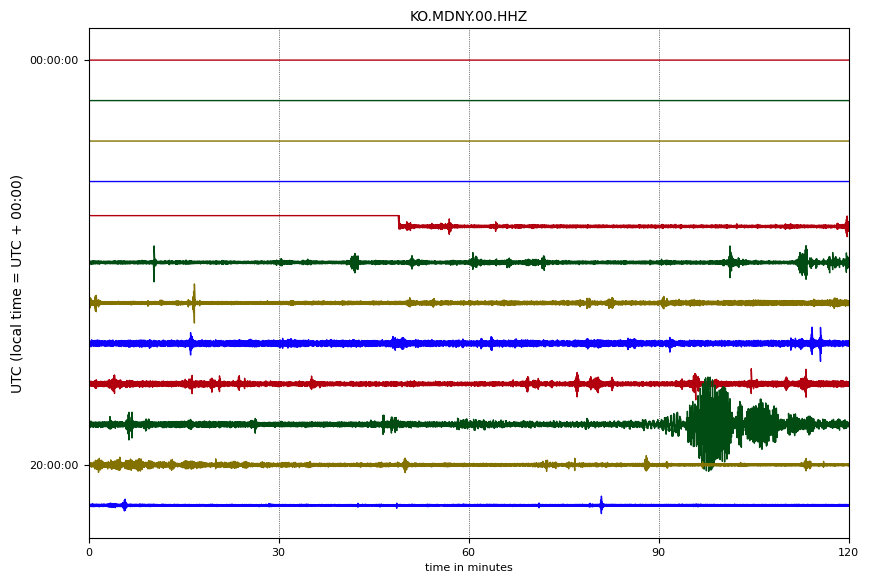

In [11]:
st_qc.select(component="Z").plot(type="dayplot", size=(1000, 600), interval=120);

### Exercise 2

- Are there suspiciously quiet intervals?
- Do all three components behave similarly?
- Does the dayplot make it easier to see long-duration changes through the day?

## 8. Read the StationXML metadata for KO.MDNY

In [12]:
inv_qc = read_inventory(str(qc_stationxml_file))
print(inv_qc)

Inventory created at 2026-09-25T09:29:50.002263Z
	Sending institution: SeisComP (KOERI)
	Contains:
		Networks (1):
			KO
		Stations (1):
			KO.MDNY (Mudanya, Bursa, Turkiye)
		Channels (3):
			KO.MDNY..HHZ, KO.MDNY..HHN, KO.MDNY..HHE


## 9. Match waveform and response metadata

The waveform files use location code `00`, while the StationXML metadata use an **empty** location code.
ObsPy looks up the response by the exact SEED id `NETWORK.STATION.LOCATION.CHANNEL`, so the two must match.
Here we simply clear the location code of the waveforms.

In [13]:
for tr in st_qc:
    print("Before:", tr.id)

for tr in st_qc:
    tr.stats.location = ""

print()
for tr in st_qc:
    print("After: ", tr.id)

Before: KO.MDNY.00.HHE
Before: KO.MDNY.00.HHN
Before: KO.MDNY.00.HHZ

After:  KO.MDNY..HHE
After:  KO.MDNY..HHN
After:  KO.MDNY..HHZ


In [14]:
tr_test = st_qc.select(component="Z")[0]
response = inv_qc.get_response(tr_test.id, tr_test.stats.starttime)
print(response)

Channel Response
	From m/s (Velocity in Meters Per Second) to COUNTS ()
	Overall Sensitivity: 1.87008e+09 defined at 1.000 Hz
	10 stages:
		Stage 1: PolesZerosResponseStage from m/s to V, gain: 5980
		Stage 2: CoefficientsTypeResponseStage from V to COUNTS, gain: 312695
		Stage 3: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 4: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 7: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 8: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 9: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 10: FIRResponseStage from COUNTS to COUNTS, gain: 1


## 10. Check for timing gaps

An empty gap list only means the timestamps are continuous.
It does **not** guarantee that every interval contains valid seismic data.

In [15]:
gaps = st_qc.get_gaps()
print(f"Number of gaps/overlaps: {len(gaps)}")
st_qc.print_gaps()

Number of gaps/overlaps: 0
Source            Last Sample                 Next Sample                 Delta           Samples 
Total: 0 gap(s) and 0 overlap(s)


## 11. Detect suspicious intervals using hourly RMS

Artificially filled gaps can look like unrealistically quiet seismic data.

In [16]:
def windowed_rms(trace, window_length=3600.0):
    # RMS of the demeaned signal in consecutive, non-overlapping windows.
    fs = trace.stats.sampling_rate
    nwin = int(window_length * fs)

    times = []
    rms_values = []

    for i0 in range(0, len(trace.data) - nwin + 1, nwin):
        x = trace.data[i0:i0 + nwin].astype(float)
        x -= x.mean()

        times.append((trace.stats.starttime + i0 / fs).datetime)
        rms_values.append(np.sqrt(np.mean(x**2)))

    return times, np.asarray(rms_values)

KO.MDNY..HHE: 8 of 24 hourly windows have RMS = 0 (no signal at all)
KO.MDNY..HHN: 8 of 24 hourly windows have RMS = 0 (no signal at all)
KO.MDNY..HHZ: 8 of 24 hourly windows have RMS = 0 (no signal at all)


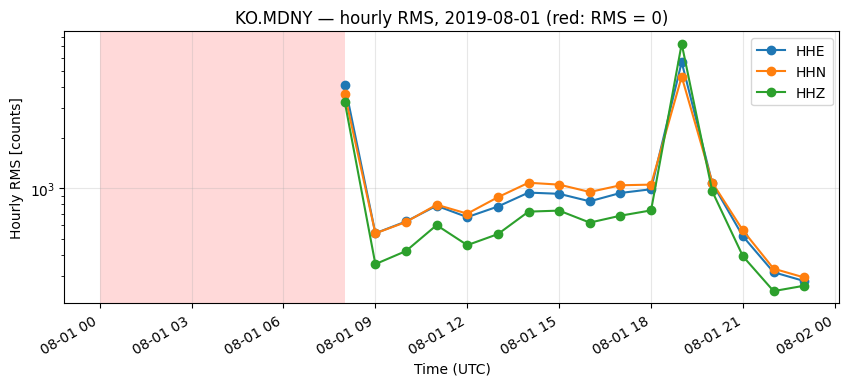

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

for tr in st_qc:
    times, rms = windowed_rms(tr)
    ax.plot(times, np.where(rms > 0, rms, np.nan), marker="o", label=tr.stats.channel)

    # A log axis cannot show RMS = 0, so report and shade dead windows explicitly.
    dead = rms == 0
    if dead.any():
        print(f"{tr.id}: {dead.sum()} of {len(rms)} hourly windows have RMS = 0 (no signal at all)")

times, rms = windowed_rms(st_qc.select(component="Z")[0])
for t0, is_dead in zip(times, rms == 0):
    if is_dead:
        ax.axvspan(t0, t0 + (times[1] - times[0]), color="red", alpha=0.15, lw=0)

ax.set_yscale("log")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Hourly RMS [counts]")
ax.set_title(f"{QC_STATION} — hourly RMS, {day_start.date} (red: RMS = 0)")
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.show()

### Exercise 3

Discuss:

1. Could an extremely low-RMS interval represent real environmental quiet?
2. What would a zero-filled gap look like?
3. Why are filled gaps problematic for ambient-noise analysis?

# Part 2 — Main analysis using KO.SLVT

## 12. Read one day of continuous data for the main analysis station

We now switch to the main station, **KO.SLVT** (set by `MAIN_STATION`), which we use for the PPSD analysis.
As for KO.MDNY, we clear the location code so that the waveforms match the StationXML.

In [18]:
data_file, stationxml_file = build_station_paths(MAIN_STATION)

print("Waveform:  ", data_file)
print("StationXML:", stationxml_file)

st = read(str(data_file))
for tr in st:
    tr.stats.location = ""   # match the empty location code in the StationXML
print(st)

inv = read_inventory(str(stationxml_file))
print(inv)

Waveform:   /content/ambient_noise_data/KO.SLVT.00/KO.SLVT.00.HH.2019.213.mseed
StationXML: /content/ambient_noise_data/KO.SLVT.00/KO.SLVT.HH.xml
3 Trace(s) in Stream:
KO.SLVT..HHE | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples
KO.SLVT..HHN | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples
KO.SLVT..HHZ | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples
Inventory created at 2026-09-25T09:29:48.256926Z
	Sending institution: SeisComP (KOERI)
	Contains:
		Networks (1):
			KO
		Stations (1):
			KO.SLVT (Silivri, Istanbul, Turkiye)
		Channels (3):
			KO.SLVT..HHZ, KO.SLVT..HHN, KO.SLVT..HHE


## 13. Plot the main-station stream and dayplot

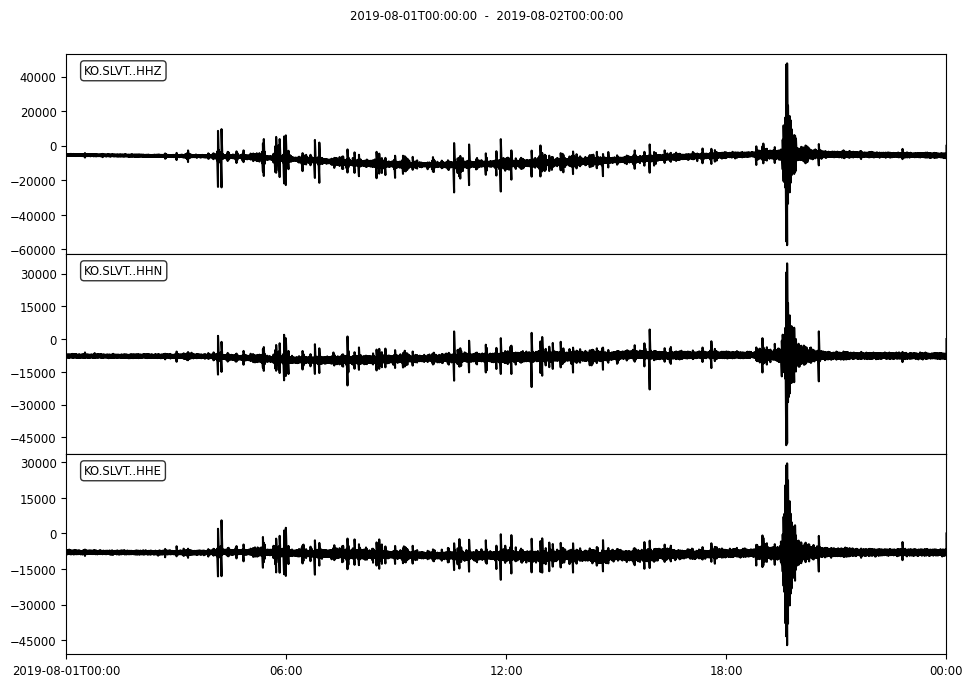

In [19]:
st.plot(equal_scale=False, size=(1000, 700));

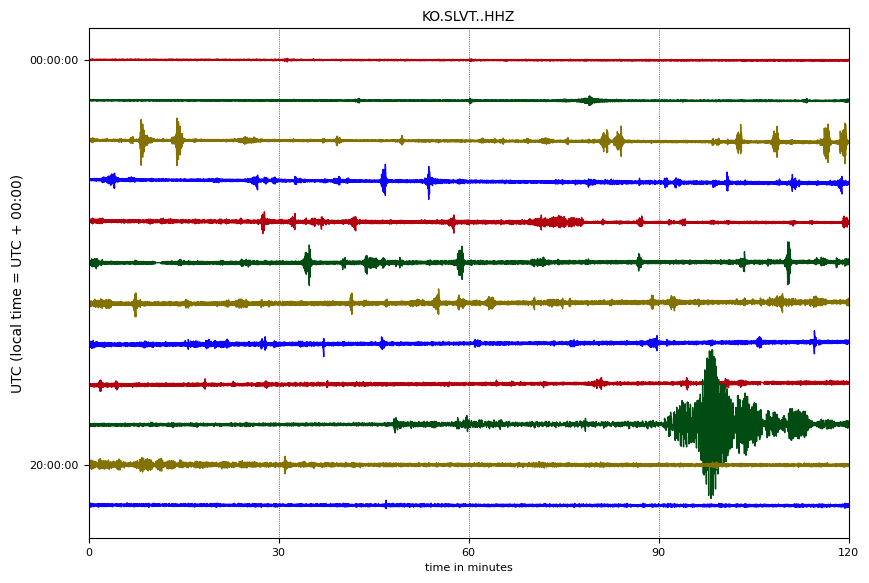

In [20]:
st.select(component="Z").plot(type="dayplot", size=(1000, 600), interval=120);

## 14. Select the vertical component

We begin the PPSD analysis with the vertical component (`HHZ`).

In [21]:
tr = st.select(component="Z")[0].copy()
print(tr)

KO.SLVT..HHZ | 2019-08-01T00:00:00.000000Z - 2019-08-02T00:00:00.000000Z | 100.0 Hz, 8640001 samples


## 15. Create a PPSD object

We use one-hour segments with 50% overlap.

In [22]:
ppsd = PPSD(
    tr.stats,
    metadata=inv,
    ppsd_length=3600.0,
    overlap=0.5,
)

print(ppsd)

## 16. Add waveform data

In [23]:
added = ppsd.add(tr)

print("Data added:", added)
print("Processed PSD segments:", len(ppsd.times_processed))

Data added: True
Processed PSD segments: 47


## 17. Plot the PPSD

The Peterson New High Noise Model (NHNM) and New Low Noise Model (NLNM) provide reference broadband seismic-noise levels.

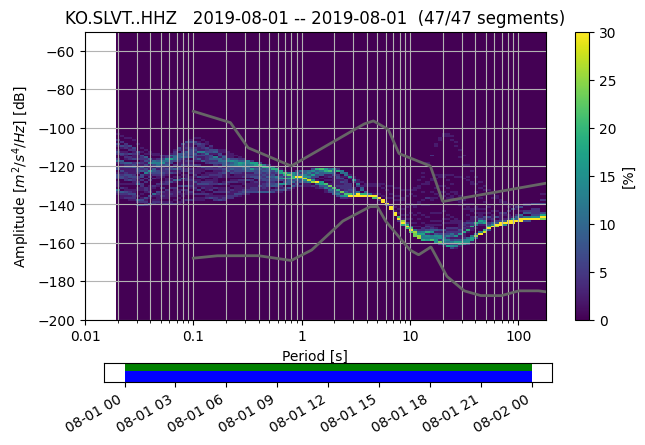

In [24]:
ppsd.plot(
    show_noise_models=True,
    show_coverage=True,
    show_histogram=True,
);

### Exercise 4

- At which periods is noise most stable?
- Where is the distribution broad?
- Are there narrow spectral features?

## 18. Temporal evolution of selected bands

We inspect approximately:

- 0.2 s (~5 Hz)
- 1 s (~1 Hz)
- 5 s (~0.2 Hz)

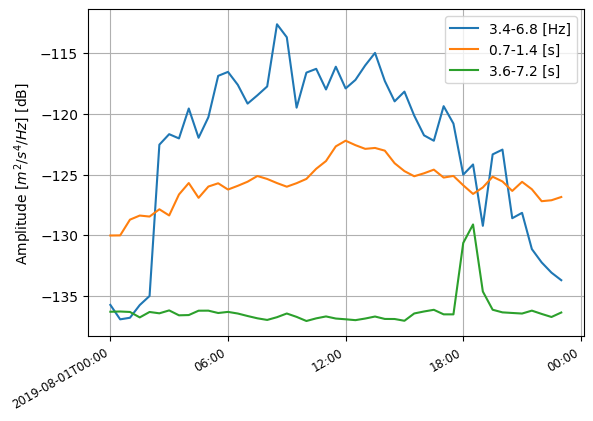

In [25]:
ppsd.plot_temporal(period=[0.2, 1.0, 5.0]);

### Exercise 5

- Which band varies most strongly through the day?
- Are sharp transient increases visible?
- Which band appears least affected by local daytime activity?
- Would one day be enough to characterize the station robustly?

## 19. Interim summary

We have now seen that:

1. miniSEED stores waveform samples,
2. StationXML provides metadata and instrument response,
3. waveform and metadata identifiers must match,
4. timing continuity does not guarantee valid data,
5. simple RMS diagnostics can reveal filled/dead intervals,
6. PPSD describes both typical seismic-noise level and variability,
7. temporal PSD analysis reveals how noise changes through time.

# Part 3 — How does seismic noise vary through the week?

So far we have inspected one day of data. We now use the complete one-week record of the main station (**KO.SLVT**) to investigate whether seismic noise follows a daily cycle.

In particular, we will ask:

- Does noise increase during daytime?
- Is the behavior frequency dependent?
- Are weekdays and weekends different?
- Which part of the spectrum appears most sensitive to human activity?

For this section we continue to use the **Probabilistic Power Spectral Density (PPSD)**.
Because the PSD windows are one hour long with 50% overlap, each valid continuous day contributes a new spectral estimate every 30 minutes.

## 20. Find all daily waveform files for the main station

In [26]:
week_files = sorted(station_dir_for(MAIN_STATION).glob("*.mseed"))

if not week_files:
    raise FileNotFoundError(f"No miniSEED files found in {station_dir_for(MAIN_STATION)}")

print(f"Station: {MAIN_STATION}")
print(f"Number of daily files: {len(week_files)}")
for f in week_files:
    print(" ", f.name)

Station: KO.SLVT
Number of daily files: 7
  KO.SLVT.00.HH.2019.213.mseed
  KO.SLVT.00.HH.2019.214.mseed
  KO.SLVT.00.HH.2019.215.mseed
  KO.SLVT.00.HH.2019.216.mseed
  KO.SLVT.00.HH.2019.217.mseed
  KO.SLVT.00.HH.2019.218.mseed
  KO.SLVT.00.HH.2019.219.mseed


## 21. Excluding artificially dead data

Earlier we saw that a file can be continuous in time while containing artificially filled sections.

For the one-week PPSD we therefore perform a simple quality-control step before adding data to the PPSD:

- divide each day into short QC windows,
- calculate the standard deviation of each component,
- identify windows whose amplitude is many orders of magnitude below the typical level,
- retain only intervals for which all three components contain valid data.

This is deliberately a conservative detector for clearly dead/filled sections. It is not intended to remove naturally quiet seismic noise.

In [27]:
def find_valid_3c_intervals(st, qc_window=300.0, relative_std_threshold=1e-4):
    """
    Return a list of (start, end) UTCDateTime pairs during which
    all three components (E, N, Z) contain valid, non-dead data.
    """
    components = [st.select(component=c) for c in ("E", "N", "Z")]
    if not all(len(x) for x in components):
        raise ValueError("A complete E/N/Z three-component record is required.")

    traces = [x[0] for x in components]
    fs = traces[0].stats.sampling_rate
    if not all(np.isclose(tr.stats.sampling_rate, fs) for tr in traces):
        raise ValueError("Components have different sampling rates.")

    # Restrict all components to their common time span.
    start = max(tr.stats.starttime for tr in traces)
    end = min(tr.stats.endtime for tr in traces)
    traces = [tr.copy().trim(start, end) for tr in traces]

    n_samples = min(len(tr.data) for tr in traces)
    nwin = int(qc_window * fs)
    starts = np.arange(0, n_samples, nwin)

    # Standard deviation of every QC window, per component.
    std_by_component = np.array([
        [np.nanstd(np.asarray(tr.data[i0:min(i0 + nwin, n_samples)], dtype=float))
         for i0 in starts]
        for tr in traces
    ])

    # A window is "good" if its std is not orders of magnitude below the typical level.
    good_components = []
    for stds in std_by_component:
        positive = stds[np.isfinite(stds) & (stds > 0)]
        if len(positive) == 0:
            return []
        threshold = np.median(positive) * relative_std_threshold
        good_components.append(np.isfinite(stds) & (stds > threshold))

    good = np.all(good_components, axis=0)

    # Join consecutive good windows into continuous intervals.
    intervals = []
    block_start = None
    for i, is_good in enumerate(good):
        if is_good and block_start is None:
            block_start = i

        if block_start is not None:
            closes_here = not is_good
            closes_at_end = is_good and i == len(good) - 1

            if closes_here or closes_at_end:
                last_good = i - 1 if closes_here else i
                sample_start = starts[block_start]
                sample_end = min(starts[last_good] + nwin, n_samples)
                intervals.append((start + sample_start / fs, start + sample_end / fs))
                block_start = None

    return intervals

Let's check the valid-data coverage of each day before computing the week-long PPSD.

In [28]:
for f in week_files:
    intervals = find_valid_3c_intervals(read(str(f)))
    valid_hours = sum((t1 - t0) / 3600 for t0, t1 in intervals)
    print(f"{f.name}: {len(intervals)} valid block(s), {valid_hours:.1f} h valid")

KO.SLVT.00.HH.2019.213.mseed: 1 valid block(s), 24.0 h valid
KO.SLVT.00.HH.2019.214.mseed: 1 valid block(s), 24.0 h valid
KO.SLVT.00.HH.2019.215.mseed: 1 valid block(s), 24.0 h valid
KO.SLVT.00.HH.2019.216.mseed: 1 valid block(s), 24.0 h valid
KO.SLVT.00.HH.2019.217.mseed: 1 valid block(s), 24.0 h valid
KO.SLVT.00.HH.2019.218.mseed: 1 valid block(s), 24.0 h valid
KO.SLVT.00.HH.2019.219.mseed: 1 valid block(s), 24.0 h valid


### Exercise 6

- Why is it preferable to exclude invalid intervals rather than replace them with zeros?
- Change `MAIN_STATION` to `"KO.MDNY"` or `"KO.BGKT"` and run this check again. What do you find?

## 22. Compute a one-week PPSD

We initially use the **vertical component** because it gives us a simple way to visualize changes in the background noise.

You can later change `PPSD_COMPONENT = "Z"` to `"N"` or `"E"` and compare components.

In [29]:
PPSD_COMPONENT = "Z"

_, week_stationxml_file = build_station_paths(MAIN_STATION)
inv_week = read_inventory(str(week_stationxml_file))

st_first = read(str(week_files[0]))
for tr in st_first:
    tr.stats.location = ""

ppsd_week = PPSD(
    st_first.select(component=PPSD_COMPONENT)[0].stats,
    metadata=inv_week,
    ppsd_length=3600.0,
    overlap=0.5,
)

In [30]:
for i, f in enumerate(week_files, start=1):
    print(f"[{i}/{len(week_files)}] {f.name}")

    st_day = read(str(f))
    for tr in st_day:
        tr.stats.location = ""

    for t0, t1 in find_valid_3c_intervals(st_day):
        block = st_day.select(component=PPSD_COMPONENT)[0].copy()
        block.trim(starttime=t0, endtime=t1, nearest_sample=False)
        ppsd_week.add(block)

print()
print("Processed one-hour PSD segments:", len(ppsd_week.times_processed))

[1/7] KO.SLVT.00.HH.2019.213.mseed
[2/7] KO.SLVT.00.HH.2019.214.mseed
[3/7] KO.SLVT.00.HH.2019.215.mseed
[4/7] KO.SLVT.00.HH.2019.216.mseed
[5/7] KO.SLVT.00.HH.2019.217.mseed
[6/7] KO.SLVT.00.HH.2019.218.mseed
[7/7] KO.SLVT.00.HH.2019.219.mseed

Processed one-hour PSD segments: 329


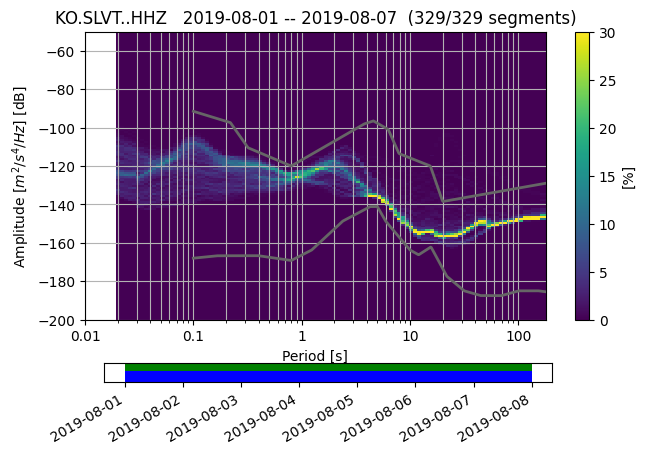

In [31]:
ppsd_week.plot(
    show_noise_models=True,
    show_coverage=True,
    show_histogram=True,
);

### Exercise 7

- At which periods is the station PSD most variable?
- Are there frequency bands that appear unusually narrow or stable?

# Part 3b — Fold the week into a 24-hour cycle

The previous figure tells us the statistical distribution of noise, but not *when* the changes occur.

We now reorganize the one-hour PSD estimates according to **local time in Türkiye**.
The raw seismic data remain in UTC. For this particular analysis, however, local civil time is more informative because we want to compare the noise with human activity.

Türkiye uses **UTC+3** throughout the year.

## 23. Extract selected PPSD bands into a table

In [32]:
SELECTED_PERIODS = [0.2, 1.0, 5.0]


def ppsd_temporal_dataframe(ppsd, selected_periods, timezone="Europe/Istanbul"):
    psd_values = np.asarray(ppsd.psd_values)
    period_bins = np.asarray(ppsd.period_bin_centers)

    timestamps = pd.to_datetime([t.datetime for t in ppsd.times_processed], utc=True)

    # Use the midpoint of each 1-hour PSD window, in local time.
    timestamps = (timestamps + pd.Timedelta(minutes=30)).tz_convert(timezone)

    rows = []
    for requested_period in selected_periods:
        idx = np.argmin(np.abs(period_bins - requested_period))
        actual_period = period_bins[idx]

        for timestamp, value in zip(timestamps, psd_values[:, idx]):
            rows.append({
                "time_local": timestamp,
                "date": timestamp.date(),
                "day_name": timestamp.day_name(),
                "is_weekend": timestamp.dayofweek >= 5,
                "local_hour": timestamp.hour + timestamp.minute / 60,
                "requested_period_s": requested_period,
                "period_s": actual_period,
                "frequency_hz": 1.0 / actual_period,
                "power_db": value,
            })

    return pd.DataFrame(rows)


noise_time = ppsd_temporal_dataframe(ppsd_week, SELECTED_PERIODS)
noise_time.head()

,time_local,date,day_name,is_weekend,local_hour,requested_period_s,period_s,frequency_hz,power_db
0,2019-08-01 03:30:00+03:00,2019-08-01,Thursday,False,3.5,0.2,0.207494,4.819409,-135.732895
1,2019-08-01 04:00:00+03:00,2019-08-01,Thursday,False,4.0,0.2,0.207494,4.819409,-136.923477
2,2019-08-01 04:30:00+03:00,2019-08-01,Thursday,False,4.5,0.2,0.207494,4.819409,-136.792679
3,2019-08-01 05:00:00+03:00,2019-08-01,Thursday,False,5.0,0.2,0.207494,4.819409,-135.744064
4,2019-08-01 05:30:00+03:00,2019-08-01,Thursday,False,5.5,0.2,0.207494,4.819409,-134.999466


## 24. Daily noise cycle, day by day

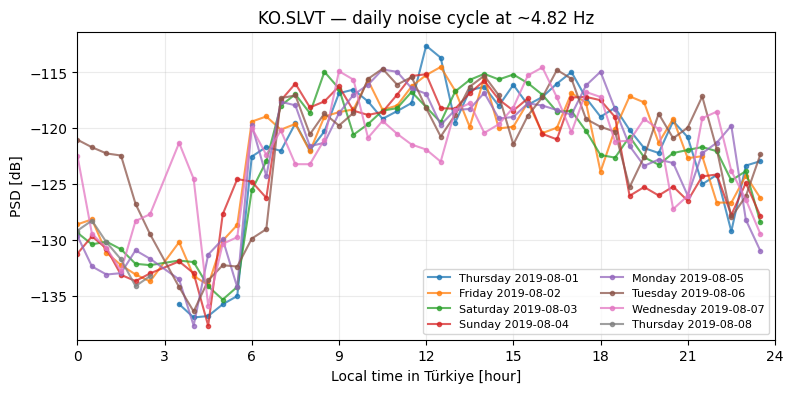

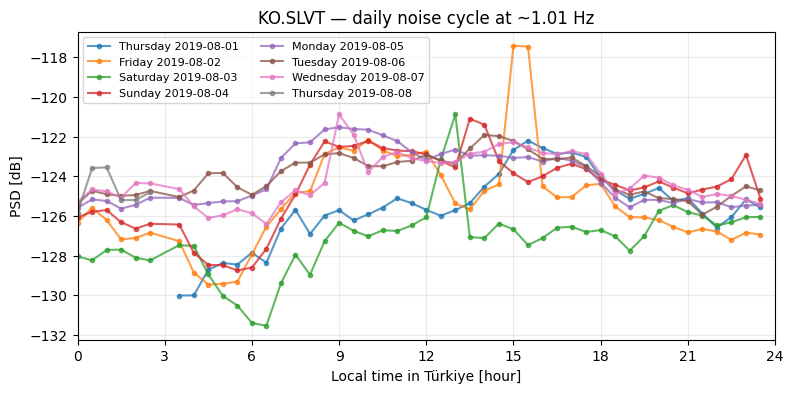

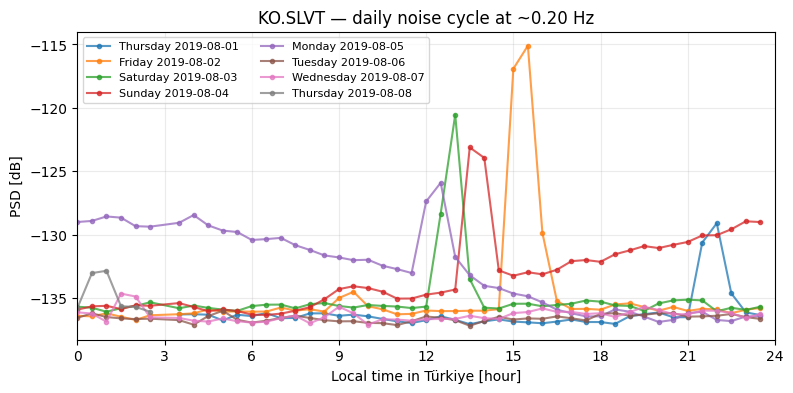

In [33]:
for requested_period in SELECTED_PERIODS:
    subset = noise_time[noise_time["requested_period_s"] == requested_period]
    actual_frequency = subset["frequency_hz"].iloc[0]

    fig, ax = plt.subplots(figsize=(9, 4))

    for date, day in subset.groupby("date"):
        ax.plot(day["local_hour"], day["power_db"], marker=".", alpha=0.75,
                label=f'{day["day_name"].iloc[0]} {date}')

    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 3))
    ax.set_xlabel("Local time in Türkiye [hour]")
    ax.set_ylabel("PSD [dB]")
    ax.set_title(f"{MAIN_STATION} — daily noise cycle at ~{actual_frequency:.2f} Hz")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2, loc="best")

    plt.show()

## 24b. What causes the transient spikes?

Some hours stand out far above the normal daily cycle, especially around 0.2 Hz (5 s) between 10:00 and 16:00 local time.
We first list the windows that are much noisier than the same hour on the other days, then look at the waveforms around them.
The waveforms are converted to ground velocity and band-pass filtered around the two PSD bands.

In [47]:
# Find hours that are unusually noisy compared with the same hour on the other days.
TRANSIENT_HOURS = (10, 16)      # local-time range to search
TRANSIENT_PERIODS = [1.0, 5.0]  # ~1 Hz and ~0.2 Hz
MIN_EXCESS_DB = 6.0             # how far above the typical level a window must be

nt = noise_time[noise_time["requested_period_s"].isin(TRANSIENT_PERIODS)].copy()

# "Typical" level = median over all days at the same local hour and period.
nt["excess_db"] = nt["power_db"] - nt.groupby(
    ["requested_period_s", "local_hour"])["power_db"].transform("median")

candidates = nt[
    nt["local_hour"].between(*TRANSIENT_HOURS)
    & (nt["excess_db"] >= MIN_EXCESS_DB)
]

# Keep the strongest window per day, and add its time in UTC.
transients = (
    candidates.sort_values("excess_db", ascending=False)
    .groupby("date").head(1)
    .sort_values("time_local")
    .assign(time_utc=lambda d: d["time_local"].dt.tz_convert("UTC"))
    [["time_local", "time_utc", "day_name", "requested_period_s", "power_db", "excess_db"]]
    .reset_index(drop=True)
)

transients

,time_local,time_utc,day_name,requested_period_s,power_db,excess_db
0,2019-08-02 15:30:00+03:00,2019-08-02 12:30:00+00:00,Friday,5.0,-115.100105,20.347954
1,2019-08-03 13:00:00+03:00,2019-08-03 10:00:00+00:00,Saturday,5.0,-120.542992,15.485558
2,2019-08-04 13:30:00+03:00,2019-08-04 10:30:00+00:00,Sunday,5.0,-123.124733,12.877693
3,2019-08-05 12:30:00+03:00,2019-08-05 09:30:00+00:00,Monday,5.0,-125.912270,10.118294


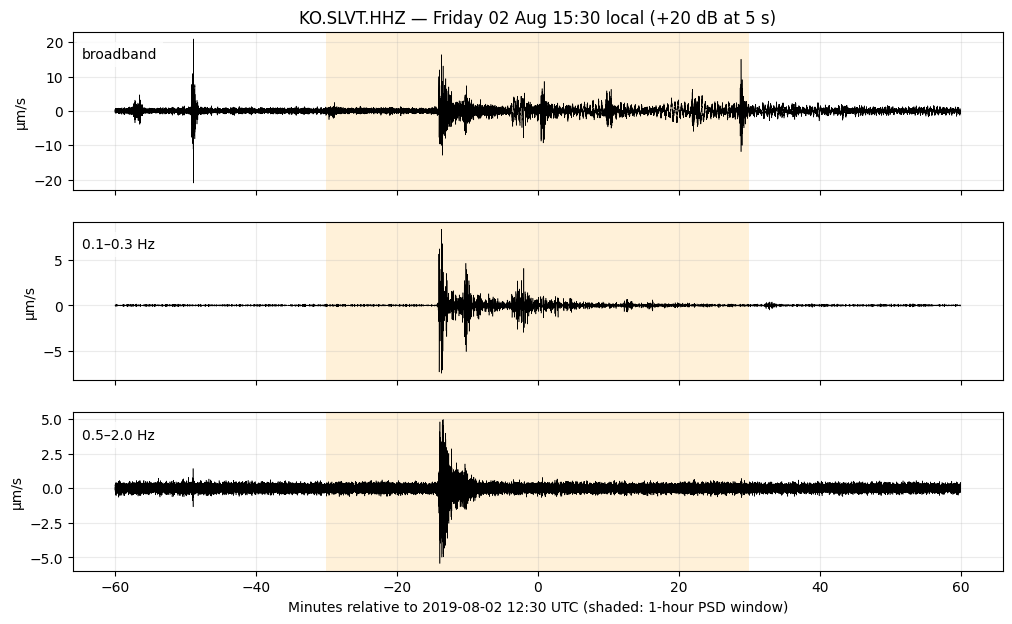

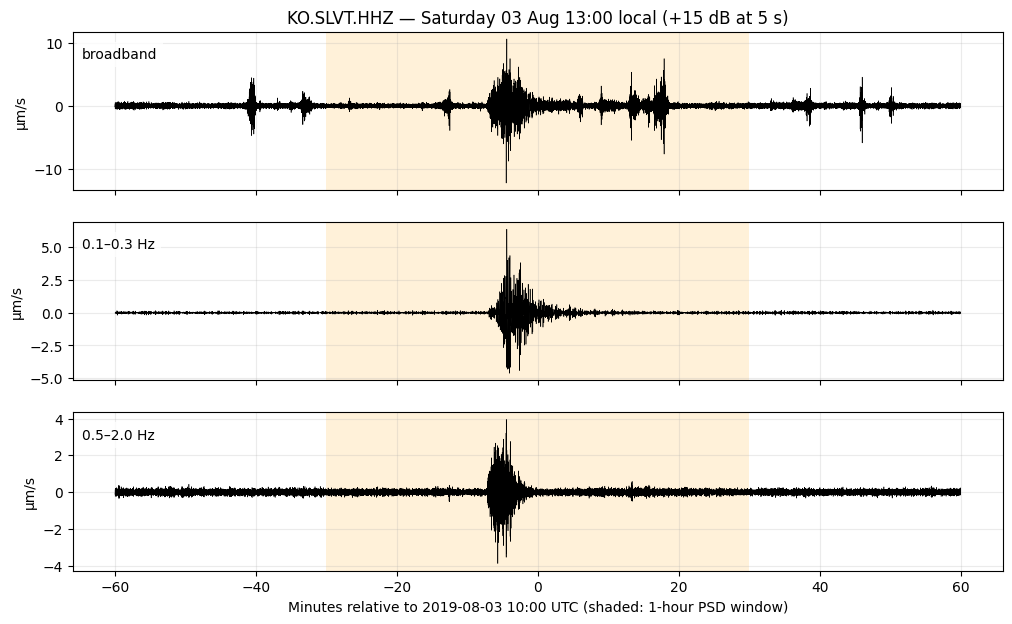

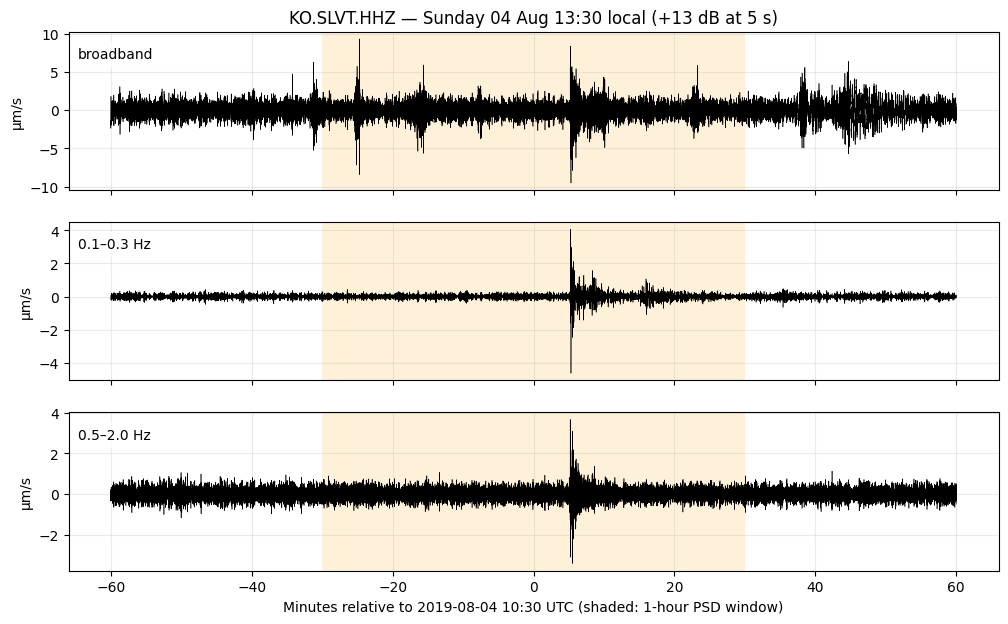

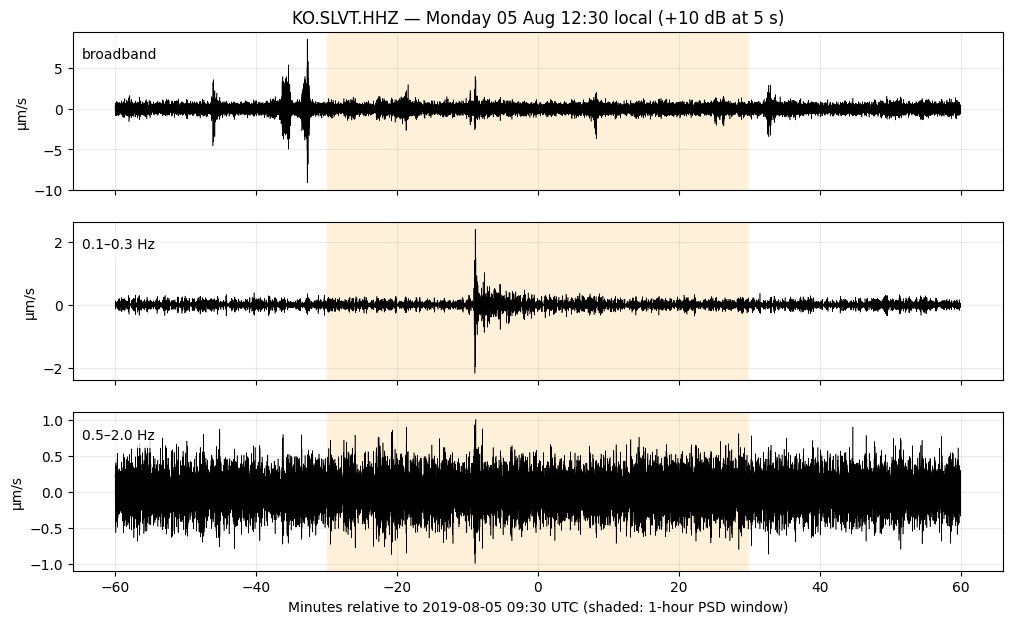

In [48]:
BANDS = [(0.1, 0.3), (0.5, 2.0)]   # around 5 s (0.2 Hz) and 1 s (1 Hz)


def read_main_station(t_start, t_end):
    # Read the vertical component of MAIN_STATION between two UTC times (may cross midnight).
    st_win = Stream()
    for jday in sorted({t_start.julday, t_end.julday}):
        waveform_file, _ = build_station_paths(MAIN_STATION, jday=jday)
        st_win += read(str(waveform_file)).select(component="Z")
    for tr in st_win:
        tr.stats.location = ""
    st_win.merge(method=1)
    return st_win.trim(t_start, t_end)


def plot_transient(time_utc, title, half_width_min=60):
    # The PSD value at time_utc comes from the 1-hour window centred on it (shaded).
    t_mid = UTCDateTime(time_utc.to_pydatetime())
    pad = 600   # extra seconds to absorb filter and taper edge effects
    t0 = t_mid - half_width_min * 60
    t1 = t_mid + half_width_min * 60

    st_win = read_main_station(t0 - pad, t1 + pad)
    st_win.detrend("linear")
    st_win.taper(0.05)
    st_win.remove_response(inventory=inv_week, output="VEL",
                           pre_filt=[0.02, 0.04, 40.0, 45.0])

    fig, axes = plt.subplots(len(BANDS) + 1, 1, figsize=(12, 7), sharex=True)
    traces = [("broadband", st_win[0].copy())] + [
        (f"{fmin}–{fmax} Hz",
         st_win[0].copy().filter("bandpass", freqmin=fmin, freqmax=fmax,
                                 corners=4, zerophase=True))
        for fmin, fmax in BANDS
    ]

    for ax, (label, tr) in zip(axes, traces):
        tr.trim(t0, t1)
        t_min = (tr.times() + (tr.stats.starttime - t_mid)) / 60.0
        ax.plot(t_min, tr.data * 1e6, color="black", linewidth=0.4)
        ax.axvspan(-30, 30, color="orange", alpha=0.15, lw=0)
        ax.set_ylabel("µm/s")
        ax.text(0.01, 0.9, label, transform=ax.transAxes, va="top",
                bbox=dict(facecolor="white", alpha=0.8, lw=0))
        ax.grid(alpha=0.25)

    axes[0].set_title(title)
    axes[-1].set_xlabel(f"Minutes relative to {t_mid.strftime('%Y-%m-%d %H:%M')} UTC "
                        "(shaded: 1-hour PSD window)")
    plt.show()


for _, row in transients.iterrows():
    plot_transient(
        row["time_utc"],
        f"{MAIN_STATION}.HHZ — {row['day_name']} {row['time_local']:%d %b %H:%M} local "
        f"(+{row['excess_db']:.0f} dB at {row['requested_period_s']:g} s)",
    )

In [ ]:
### Exercise 8b

- What kind of signal causes each spike? Is it a short, sharp arrival or a long, steady increase?
- Look up earthquakes of magnitude 5.5 and above for 1–7 August 2019 in the
  [USGS catalogue](https://earthquake.usgs.gov/earthquakes/search/). Do any match the arrival times?
- One transient is equally strong at 1 Hz and 0.2 Hz and lasts several minutes. Estimate its distance from the time between the P and S arrivals.
- Why do medians and percentiles (Section 25) handle these transients better than averages would?

### Exercise 8

- Which frequency band shows the clearest day/night cycle?
- Is the pattern repeatable between different days?
- At what local times does the high-frequency noise begin to increase?
- Which physical or anthropogenic sources could explain the observed behavior?

## 25. Weekday versus weekend

Because PSD is represented logarithmically in decibels and occasional transient signals can produce outliers, we use a robust summary:

- **median** noise level,
- **25th–75th percentile** range.

We compute these separately for weekdays and weekends at each 30-minute local-time interval.

With only one week of data, the weekend statistics contain only two days (Saturday 3 and Sunday 4 August). They are useful for exploration, but should not be interpreted as a long-term trend.

In [34]:
noise_time["day_type"] = np.where(noise_time["is_weekend"], "Weekend", "Weekday")

diurnal_summary = (
    noise_time
    .groupby(["requested_period_s", "frequency_hz", "day_type", "local_hour"])["power_db"]
    .agg(
        median="median",
        q25=lambda x: np.nanpercentile(x, 25),
        q75=lambda x: np.nanpercentile(x, 75),
        n="count",
    )
    .reset_index()
)

diurnal_summary.head()

,requested_period_s,frequency_hz,day_type,local_hour,median,q25,q75,n
0,0.2,4.819409,Weekday,0.0,-128.588242,-129.153046,-122.443008,5
1,0.2,4.819409,Weekday,0.5,-128.248749,-129.429077,-128.146255,5
2,0.2,4.819409,Weekday,1.0,-130.702164,-131.132751,-130.191803,5
3,0.2,4.819409,Weekday,1.5,-132.232727,-132.754135,-131.722015,5
4,0.2,4.819409,Weekday,2.0,-130.915039,-133.074936,-128.287369,5


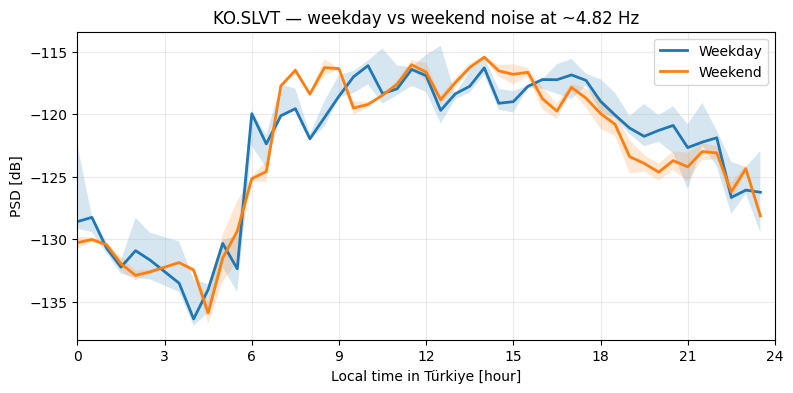

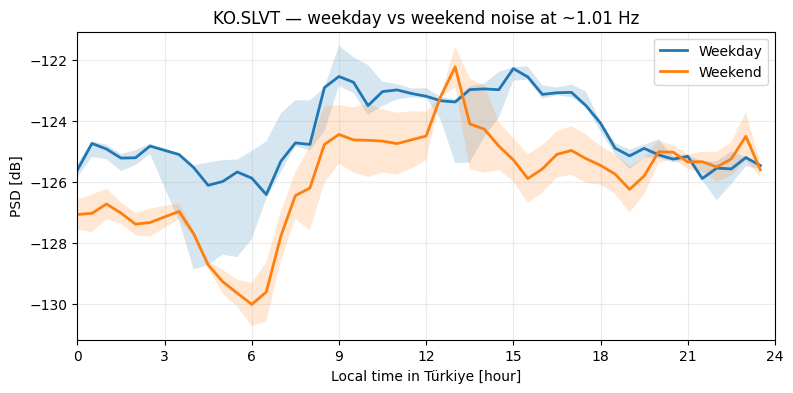

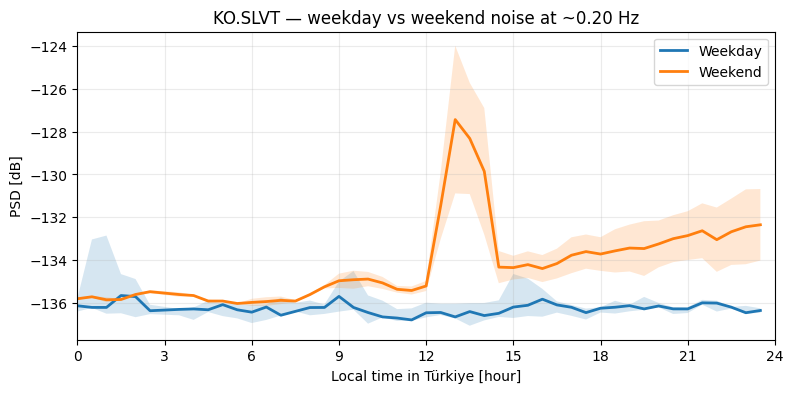

In [35]:
for requested_period in SELECTED_PERIODS:
    subset = diurnal_summary[diurnal_summary["requested_period_s"] == requested_period]
    actual_frequency = subset["frequency_hz"].iloc[0]

    fig, ax = plt.subplots(figsize=(9, 4))

    for day_type in ["Weekday", "Weekend"]:
        grp = subset[subset["day_type"] == day_type].sort_values("local_hour")
        ax.plot(grp["local_hour"], grp["median"], linewidth=2, label=day_type)
        ax.fill_between(grp["local_hour"], grp["q25"], grp["q75"], alpha=0.18)

    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 3))
    ax.set_xlabel("Local time in Türkiye [hour]")
    ax.set_ylabel("PSD [dB]")
    ax.set_title(f"{MAIN_STATION} — weekday vs weekend noise at ~{actual_frequency:.2f} Hz")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.show()

### Exercise 9

Compare the weekday and weekend curves.

- At which frequencies is the weekday/weekend difference largest?
- Is there evidence for a morning or daytime increase in noise?
- Does the longer-period noise follow the same pattern?
- Which observations are consistent with anthropogenic noise?
- Why should we be cautious when interpreting only one week of observations?

# Part 4 — Ambient noise versus an earthquake-rich wavefield

We now compare the ambient-noise records with a short interval containing many local earthquakes:
about 4.5 hours on **24 September 2019**, two days before the Silivri main shock.

The goal is not to detect or pick earthquakes. Instead, we use spectrograms to ask:

> How does an earthquake-rich wavefield differ from a more stationary ambient-noise wavefield?

## 26. Download the earthquake-rich dataset

The archive contains one folder per station (`KO.MDNY.HH`, `KO.SLVT.HH`, `KO.BGKT.HH`), each with several consecutive miniSEED files.

In [36]:
FORESHOCK_ROOT = DATA_ROOT / "waveforms_foreshocks"

if not FORESHOCK_ROOT.exists():
    foreshock_zip = DATA_ROOT / "waveforms_foreshocks.zip"
    print("Downloading earthquake-rich waveform dataset ...")
    urllib.request.urlretrieve(f"{RELEASE_BASE}/waveforms_foreshocks.zip", foreshock_zip)

    print("Extracting ...")
    with zipfile.ZipFile(foreshock_zip, "r") as zf:
        zf.extractall(DATA_ROOT)
    foreshock_zip.unlink(missing_ok=True)

print("Dataset root:", FORESHOCK_ROOT)
for d in sorted(FORESHOCK_ROOT.iterdir()):
    print(" ", d.name)

Extracting ...
Dataset root: /content/ambient_noise_data/waveforms_foreshocks
  KO.BGKT.HH
  KO.MDNY.HH
  KO.SLVT.HH


## 27. Read and merge the waveform files

We use the same station as before (`MAIN_STATION`).
The files are stored as many short records with tiny gaps and one-sample overlaps between them.
`Stream.merge()` joins them into one continuous trace per component; the few short gaps are filled by linear interpolation.

In [37]:
EVENT_STATION = MAIN_STATION

event_files = sorted((FORESHOCK_ROOT / f"{EVENT_STATION}.HH").glob("*.mseed"))
print(f"Station: {EVENT_STATION}")
print(f"Number of waveform files: {len(event_files)}")

st_event = Stream()
for f in event_files:
    st_event += read(str(f))

print(f"\nBefore merge: {len(st_event)} traces")
gaps = st_event.get_gaps()
print(f"Gaps/overlaps: {len(gaps)} (longest: {max((abs(g[6]) for g in gaps), default=0):.2f} s)")

st_event.merge(method=1, fill_value="interpolate")
print("\nAfter merge:")
print(st_event)

Station: KO.SLVT
Number of waveform files: 5

Before merge: 1019 traces
Gaps/overlaps: 8 (longest: 5.00 s)

After merge:
3 Trace(s) in Stream:
KO.SLVT..HHE | 2019-09-24T07:25:00.000000Z - 2019-09-24T11:49:59.990000Z | 100.0 Hz, 1590000 samples
KO.SLVT..HHN | 2019-09-24T07:25:00.000000Z - 2019-09-24T11:49:59.990000Z | 100.0 Hz, 1590000 samples
KO.SLVT..HHZ | 2019-09-24T07:25:00.000000Z - 2019-09-24T11:49:59.990000Z | 100.0 Hz, 1590000 samples


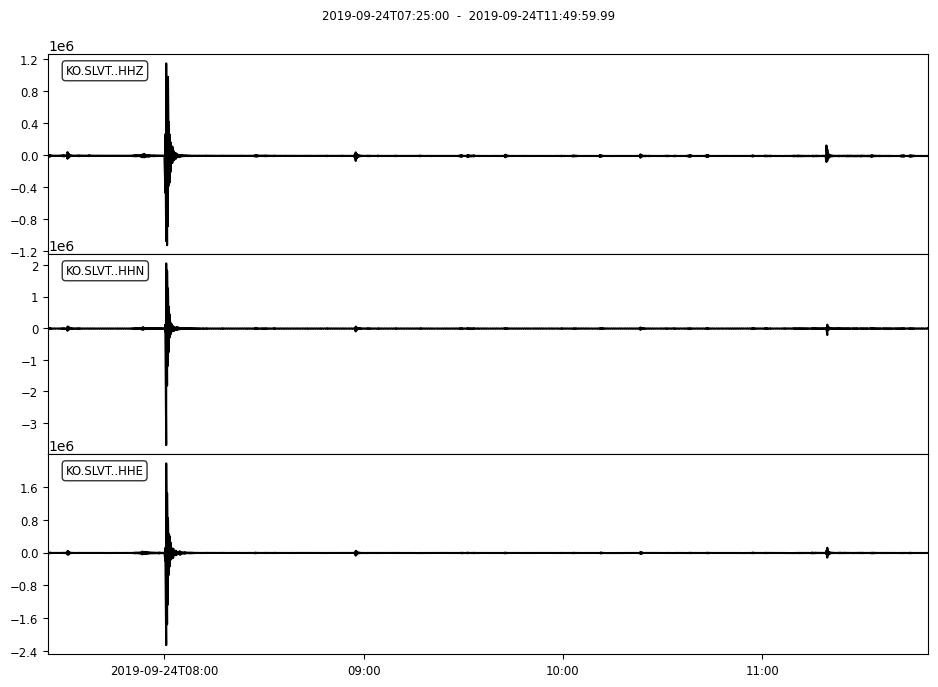

In [38]:
st_event.plot(equal_scale=False, size=(1000, 700));

## 28. Spectrogram of the earthquake-rich interval

We compute the spectrogram of the vertical component with 20 s windows and 75% overlap.

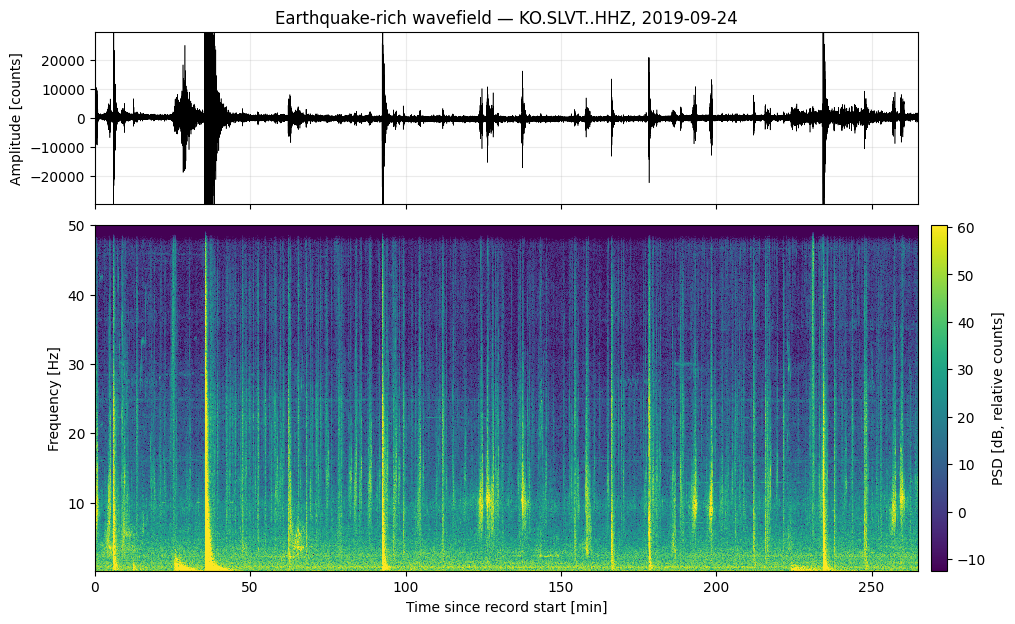

In [45]:
def compute_spectrogram_db(trace, window_s=20.0, overlap_s=15.0):
    tr = trace.copy()
    tr.detrend("demean")
    tr.detrend("linear")
    fs = tr.stats.sampling_rate

    freqs, times, sxx = spectrogram(
        tr.data.astype(float),
        fs=fs,
        nperseg=int(window_s * fs),
        noverlap=int(overlap_s * fs),
        detrend="linear",
        scaling="density",
        mode="psd",
    )
    return freqs, times, 10 * np.log10(np.maximum(sxx, np.finfo(float).tiny))


def plot_waveform_and_spectrogram(trace, freqs, times, sxx_db, title,
                                  vmin=None, vmax=None, amp_lim=None):
    # Waveform (top) and spectrogram (bottom) on the same time axis.
    tr = trace.copy()
    tr.detrend("demean")
    tr.detrend("linear")
    t_wave = np.arange(tr.stats.npts) / tr.stats.sampling_rate / 60.0

    fig, axes = plt.subplots(
        2, 2, figsize=(11, 7), sharex="col",
        gridspec_kw=dict(height_ratios=[1, 2], width_ratios=[1, 0.02], hspace=0.08, wspace=0.03),
    )
    ax_wave, ax_spec, cax = axes[0, 0], axes[1, 0], axes[1, 1]
    axes[0, 1].axis("off")   # empty slot above the colour bar keeps both panels equally wide

    ax_wave.plot(t_wave, tr.data, color="black", linewidth=0.4)
    ax_wave.set_ylabel("Amplitude [counts]")
    ax_wave.set_title(title)
    ax_wave.grid(alpha=0.25)
    if amp_lim is not None:
        ax_wave.set_ylim(-amp_lim, amp_lim)

    mesh = ax_spec.pcolormesh(times / 60.0, freqs, sxx_db, shading="auto", vmin=vmin, vmax=vmax)
    ax_spec.set_ylim(0.2, 50)
    ax_spec.set_xlim(0, t_wave[-1])
    ax_spec.set_xlabel("Time since record start [min]")
    ax_spec.set_ylabel("Frequency [Hz]")

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("PSD [dB, relative counts]")
    plt.show()


tr_event = st_event.select(component="Z")[0]
f_event, t_event, S_event_db = compute_spectrogram_db(tr_event)

# Fix the colour and amplitude scales so that the ambient-noise figure below is directly comparable.
VMIN, VMAX = np.percentile(S_event_db[(f_event >= 0.2) & (f_event <= 50)], [5, 99.5])

# The largest event would dwarf everything else, so the amplitude axis is set from the
# 99th percentile: the biggest arrivals are clipped, and the smaller earthquakes stay visible.
AMP_LIM = 2 * np.percentile(np.abs(tr_event.data - tr_event.data.mean()), 99)

plot_waveform_and_spectrogram(
    tr_event, f_event, t_event, S_event_db,
    f"Earthquake-rich wavefield — {tr_event.id}, {tr_event.stats.starttime.date}",
    VMIN, VMAX, AMP_LIM,
)

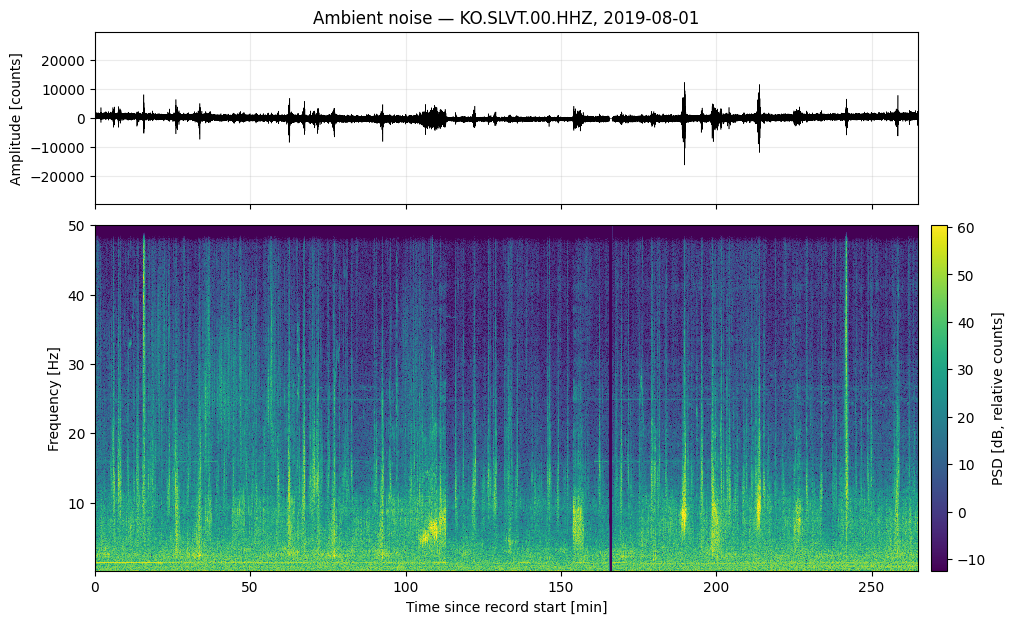

In [46]:
noise_file, _ = build_station_paths(EVENT_STATION, jday=JULIAN_DAY)
tr_noise = read(str(noise_file)).select(component="Z")[0]

event_start = tr_event.stats.starttime
noise_start = UTCDateTime(year=YEAR, julday=JULIAN_DAY,
                          hour=event_start.hour, minute=event_start.minute)
tr_noise.trim(noise_start, noise_start + (tr_event.stats.endtime - event_start))

f_noise, t_noise, S_noise_db = compute_spectrogram_db(tr_noise)

# Same amplitude scale as the earthquake-rich record. Replace AMP_LIM with None to zoom in on the noise.
plot_waveform_and_spectrogram(
    tr_noise, f_noise, t_noise, S_noise_db,
    f"Ambient noise — {tr_noise.id}, {noise_start.date}",
    VMIN, VMAX, AMP_LIM,
)

## 29. The same view for ambient noise

For comparison, we take an interval of the same length and at the same time of day from the ambient-noise week of the same station, and plot it with the **same colour scale**.

### Exercise 10

- How do individual earthquakes appear in the spectrogram (duration, frequency content)?
- Which frequency band is dominated by earthquakes, and which looks similar in both spectrograms?
- Why does a stationary noise field make spectral estimates such as PPSD  more stable?
- The ambient-noise spectrogram shows one thin dark vertical stripe. Investigate what could cause it?